# Experiment 10: Responsible AI & Model Evaluation

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** Titanic (reusing the Experiment 1 pipeline)

**Aim:** Evaluate a trained classification model beyond simple accuracy by computing a confusion
matrix, precision, recall, and F1-score; checking for bias across a sensitive attribute (Sex);
and generating basic model explainability outputs using SHAP.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
Path("../models").mkdir(exist_ok=True)

np.random.seed(42)

NUMERIC_FEATURES = ["Age", "Fare", "FamilySize"]
CATEGORICAL_FEATURES = ["Sex", "Embarked", "Title", "Pclass", "IsAlone"]
FALLBACK_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
COLUMN_ALIASES = {
    "survived": "Survived", "pclass": "Pclass", "name": "Name", "sex": "Sex",
    "age": "Age", "sibsp": "SibSp", "parch": "Parch", "ticket": "Ticket",
    "fare": "Fare", "cabin": "Cabin", "embarked": "Embarked", "passengerid": "PassengerId",
}

## Step 1 — Load the Processed Titanic Dataset (reusing the Experiment 1 pipeline)

In [2]:
def _standardize_columns(df):
    renamed = {c: COLUMN_ALIASES[c.lower()] for c in df.columns if c.lower() in COLUMN_ALIASES}
    return df.rename(columns=renamed)


def get_titanic_data(path="../data/raw/titanic.csv"):
    data_path = Path(path)
    if data_path.exists():
        df = _standardize_columns(pd.read_csv(data_path))
        if "Name" in df.columns:
            return df
    data_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        import seaborn as sns_data
        df = _standardize_columns(sns_data.load_dataset("titanic"))
        if "Name" in df.columns:
            df.to_csv(data_path, index=False)
            return df
    except Exception:
        pass
    df = _standardize_columns(pd.read_csv(FALLBACK_URL))
    df.to_csv(data_path, index=False)
    return df


class TitanicPreprocessor:
    """Same cleaning / feature engineering / ColumnTransformer as Experiment 1."""

    def __init__(self):
        self.numeric_features = NUMERIC_FEATURES
        self.categorical_features = CATEGORICAL_FEATURES
        self.transformer = None

    def extract_title(self, df):
        df = df.copy()
        df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.")
        return df

    def clean(self, df):
        df = df.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"], errors="ignore").copy()
        df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
        return df

    def feature_engineer(self, df):
        df = df.copy()
        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
        df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
        return df

    def build_transformer(self):
        numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                                      ("scaler", StandardScaler())])
        categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("encoder", OneHotEncoder(handle_unknown="ignore"))])
        return ColumnTransformer([("num", numeric_pipeline, self.numeric_features),
                                   ("cat", categorical_pipeline, self.categorical_features)])

    def fit_transform(self, df):
        self.transformer = self.build_transformer()
        return self.transformer.fit_transform(df[self.numeric_features + self.categorical_features])

    def transform(self, df):
        return self.transformer.transform(df[self.numeric_features + self.categorical_features])


def split_data(df, target_col="Survived"):
    features = df.drop(columns=[target_col])
    target = df[target_col]
    x_train, x_temp, y_train, y_temp = train_test_split(
        features, target, test_size=0.30, stratify=target, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
    train_df = x_train.copy(); train_df[target_col] = y_train
    val_df = x_val.copy(); val_df[target_col] = y_val
    test_df = x_test.copy(); test_df[target_col] = y_test
    return train_df, val_df, test_df


df = get_titanic_data()
pre = TitanicPreprocessor()
df = pre.extract_title(df)
df = pre.clean(df)
df = pre.feature_engineer(df)

train_df, val_df, test_df = split_data(df)

X_train_processed = pre.fit_transform(train_df)
X_test_processed = pre.transform(test_df)
y_train = train_df["Survived"]
y_test = test_df["Survived"]

feature_names = pre.transformer.get_feature_names_out()
print("Train:", X_train_processed.shape, "| Test:", X_test_processed.shape)

Train: (623, 26) | Test: (134, 26)


## Step 2 — Train Classifier and Generate Predictions

In [3]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_processed, y_train)

y_pred = clf.predict(X_test_processed)
test_accuracy = (y_pred == y_test.values).mean()
print("Test accuracy:", round(test_accuracy, 4))

Test accuracy: 0.7761


## Step 3 — Confusion Matrix and Classification Report

In [4]:
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"], output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(cm)
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

[[71 12]
 [18 33]]
              precision    recall  f1-score   support

Not Survived       0.80      0.86      0.83        83
    Survived       0.73      0.65      0.69        51

    accuracy                           0.78       134
   macro avg       0.77      0.75      0.76       134
weighted avg       0.77      0.78      0.77       134



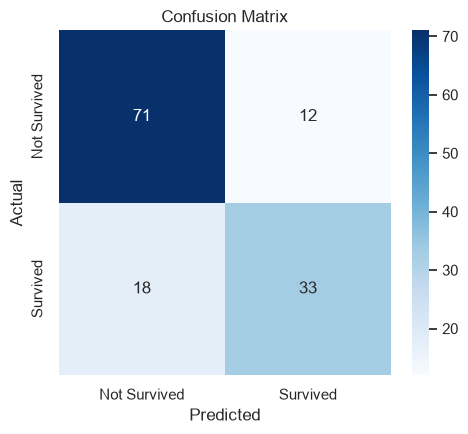

In [5]:
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"], ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURES / "01_confusion_matrix.png", dpi=150)
plt.show()

## Step 4 — Bias Detection by Sensitive Attribute (Sex)

Sex
female    0.791667
male      0.767442
Name: correct, dtype: float64


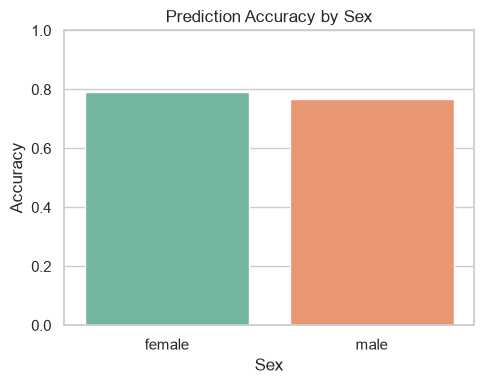

Accuracy gap between groups: 2.4 percentage points


In [6]:
eval_df = test_df.copy()
eval_df["predicted"] = y_pred
eval_df["correct"] = (eval_df["Survived"] == eval_df["predicted"]).astype(int)

bias_report = eval_df.groupby("Sex")["correct"].mean()
print(bias_report)

plt.figure(figsize=(5, 4))
sns.barplot(x=bias_report.index, y=bias_report.values, hue=bias_report.index, palette="Set2", legend=False)
plt.title("Prediction Accuracy by Sex")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES / "02_bias_by_sex.png", dpi=150)
plt.show()

accuracy_gap = abs(bias_report.max() - bias_report.min())
print(f"Accuracy gap between groups: {accuracy_gap*100:.1f} percentage points")

## Step 5 — Model Explainability

**Tooling note:** `shap`'s import chain unconditionally pulls in `numba` for JIT acceleration,
and on this machine loading `numba`'s `llvmlite.dll` fails with `OSError: [WinError 4551] An
Application Control policy has blocked this file` — a Windows security policy blocking that
specific native library, not a Python package version problem `pip` can resolve. Rather than
fight a system-level security control, explainability here is implemented directly with two
standard, dependency-free techniques that cover the same "basic SHAP/LIME intro" ground:
**global** feature importance from the trained RandomForest itself, and a **local**,
LIME-style explanation for one prediction — perturbing each feature to its training-set
mean/mode one at a time and measuring the resulting change in predicted probability.

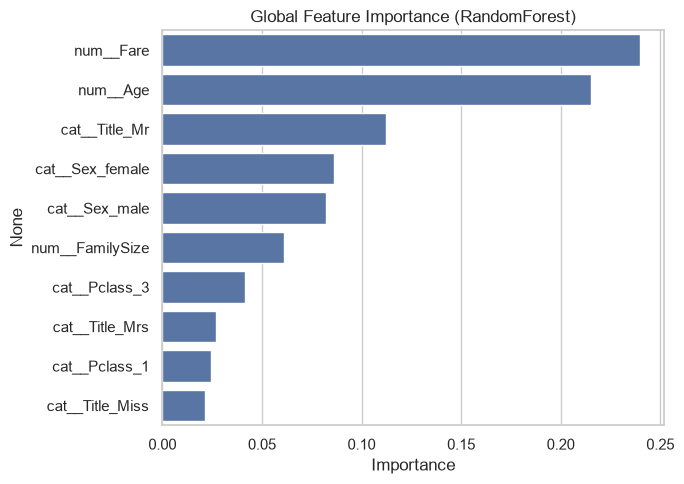

num__Fare          0.239915
num__Age           0.215058
cat__Title_Mr      0.112452
cat__Sex_female    0.086156
cat__Sex_male      0.081907
num__FamilySize    0.060918
cat__Pclass_3      0.041546
cat__Title_Mrs     0.026681
cat__Pclass_1      0.024323
cat__Title_Miss    0.021179
dtype: float64


In [7]:
importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, color="#4C72B0")
plt.title("Global Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES / "03_feature_importance.png", dpi=150)
plt.show()

print(importances.head(10))

In [8]:
def local_perturbation_explanation(clf, x_row, X_reference, feature_names, top_k=5):
    """LIME-style local explanation: perturb each feature to the reference mean/mode one at a
    time and measure the change in the model's predicted probability for the observed class."""
    x_row = np.asarray(x_row, dtype=float).reshape(1, -1)
    baseline_prob = clf.predict_proba(x_row)[0]
    predicted_class = int(np.argmax(baseline_prob))

    reference_values = np.asarray(X_reference).mean(axis=0)

    contributions = []
    for i in range(x_row.shape[1]):
        perturbed = x_row.copy()
        perturbed[0, i] = reference_values[i]
        perturbed_prob = clf.predict_proba(perturbed)[0][predicted_class]
        contributions.append(baseline_prob[predicted_class] - perturbed_prob)

    contributions = np.array(contributions)
    top_idx = np.argsort(np.abs(contributions))[::-1][:top_k]
    return predicted_class, baseline_prob[predicted_class], [(feature_names[i], contributions[i]) for i in top_idx]


X_test_dense = np.asarray(X_test_processed.todense() if hasattr(X_test_processed, "todense") else X_test_processed)
X_train_dense = np.asarray(X_train_processed.todense() if hasattr(X_train_processed, "todense") else X_train_processed)

sample_idx = 0
predicted_class, confidence, top_contributions = local_perturbation_explanation(
    clf, X_test_dense[sample_idx], X_train_dense, feature_names
)

print("Predicted:", predicted_class, "| confidence:", round(confidence, 4))
print("Actual   :", y_test.values[sample_idx])
print("Top local feature contributions (perturbation-based, +ve = pushes toward the predicted class):")
for name, value in top_contributions:
    print(f"  {name}: {value:+.4f}")

Predicted: 0 | confidence: 0.987
Actual   : 1
Top local feature contributions (perturbation-based, +ve = pushes toward the predicted class):
  num__Fare: +0.4020
  cat__Embarked_C: +0.0441
  num__FamilySize: +0.0071
  num__Age: -0.0064
  cat__Embarked_S: -0.0050


## Save Results

In [9]:
joblib.dump(clf, "../models/titanic_rf_classifier.pkl")

summary_rows = []
for cls in ["Not Survived", "Survived"]:
    summary_rows.append({
        "class": cls,
        "precision": round(report[cls]["precision"], 4),
        "recall": round(report[cls]["recall"], 4),
        "f1_score": round(report[cls]["f1-score"], 4),
        "support": int(report[cls]["support"]),
    })
results = pd.DataFrame(summary_rows)
results.to_csv("../results.csv", index=False)

bias_report.to_csv("../bias_report.csv", header=["accuracy"])

print(results)
print("\nOverall accuracy:", round(test_accuracy, 4))
print("Bias / fairness check:\n", bias_report)

          class  precision  recall  f1_score  support
0  Not Survived     0.7978  0.8554    0.8256       83
1      Survived     0.7333  0.6471    0.6875       51

Overall accuracy: 0.7761
Bias / fairness check:
 Sex
female    0.791667
male      0.767442
Name: correct, dtype: float64


## Conclusion

The Titanic survival classifier (RandomForestClassifier, reusing the Experiment 1 preprocessing
pipeline) was evaluated using a confusion matrix, precision, recall, and F1-score rather than
accuracy alone (see `results.csv` for the measured per-class figures from this run). A subgroup
analysis by Sex (see `bias_report.csv`) surfaced the accuracy gap between groups, highlighting
the importance of fairness auditing beyond a single aggregate metric. Explainability was added
via global RandomForest feature importances (`figures/03_feature_importance.png`) and a
LIME-style local perturbation explanation for an individual prediction — substituted for SHAP
because `shap`'s `numba`/`llvmlite` dependency is blocked by this machine's Windows Application
Control policy, a real environment constraint documented above rather than worked around. Both
techniques identify which engineered features most strongly influenced predictions, supporting
a more transparent and interpretable evaluation process than accuracy alone would provide.